# 客户人口统计学分析

本笔记本对购物行为数据集进行客户人口统计学分析，包括：
- 年龄分布分析（年龄段偏好）
- 性别购买行为差异
- 年龄与性别的交叉分析
- 不同年龄段的消费能力分析

## 分析目标
通过深入分析客户的人口统计特征，了解不同群体的购买行为模式，为精准营销和客户细分提供数据支持。

## 1. 导入所需库和数据

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']  # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

print("库导入完成！")

库导入完成！


In [2]:
# 读取数据
df = pd.read_csv('shopping_behavior_updated.csv')

# 显示数据基本信息
print("数据集基本信息：")
print(f"数据形状: {df.shape}")
print(f"列名: {list(df.columns)}")
print("\n前5行数据:")
df.head()

数据集基本信息：
数据形状: (3900, 18)
列名: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']

前5行数据:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 2. 数据预处理和清洗

In [3]:
# 检查数据质量
print("数据质量检查：")
print("=" * 50)

# 检查缺失值
print("缺失值情况：")
print(df.isnull().sum())

print("\n数据类型：")
print(df.dtypes)

print("\n数值型列的基本统计：")
print(df.describe())

数据质量检查：
缺失值情况：
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

数据类型：
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied   

In [4]:
# 创建年龄段分组
def create_age_groups(age):
    if age < 25:
        return '18-24岁'
    elif age < 35:
        return '25-34岁'
    elif age < 45:
        return '35-44岁'
    elif age < 55:
        return '45-54岁'
    elif age < 65:
        return '55-64岁'
    else:
        return '65岁以上'

# 应用年龄分组
df['Age_Group'] = df['Age'].apply(create_age_groups)

# 查看年龄分组分布
print("年龄段分布：")
print(df['Age_Group'].value_counts().sort_index())

# 查看性别分布
print("\n性别分布：")
print(df['Gender'].value_counts())

年龄段分布：
Age_Group
18-24岁    486
25-34岁    755
35-44岁    729
45-54岁    752
55-64岁    751
65岁以上     427
Name: count, dtype: int64

性别分布：
Gender
Male      2652
Female    1248
Name: count, dtype: int64


## 3. 年龄分布分析

年龄描述性统计：
count    3900.000000
mean       44.068462
std        15.207589
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Age, dtype: float64


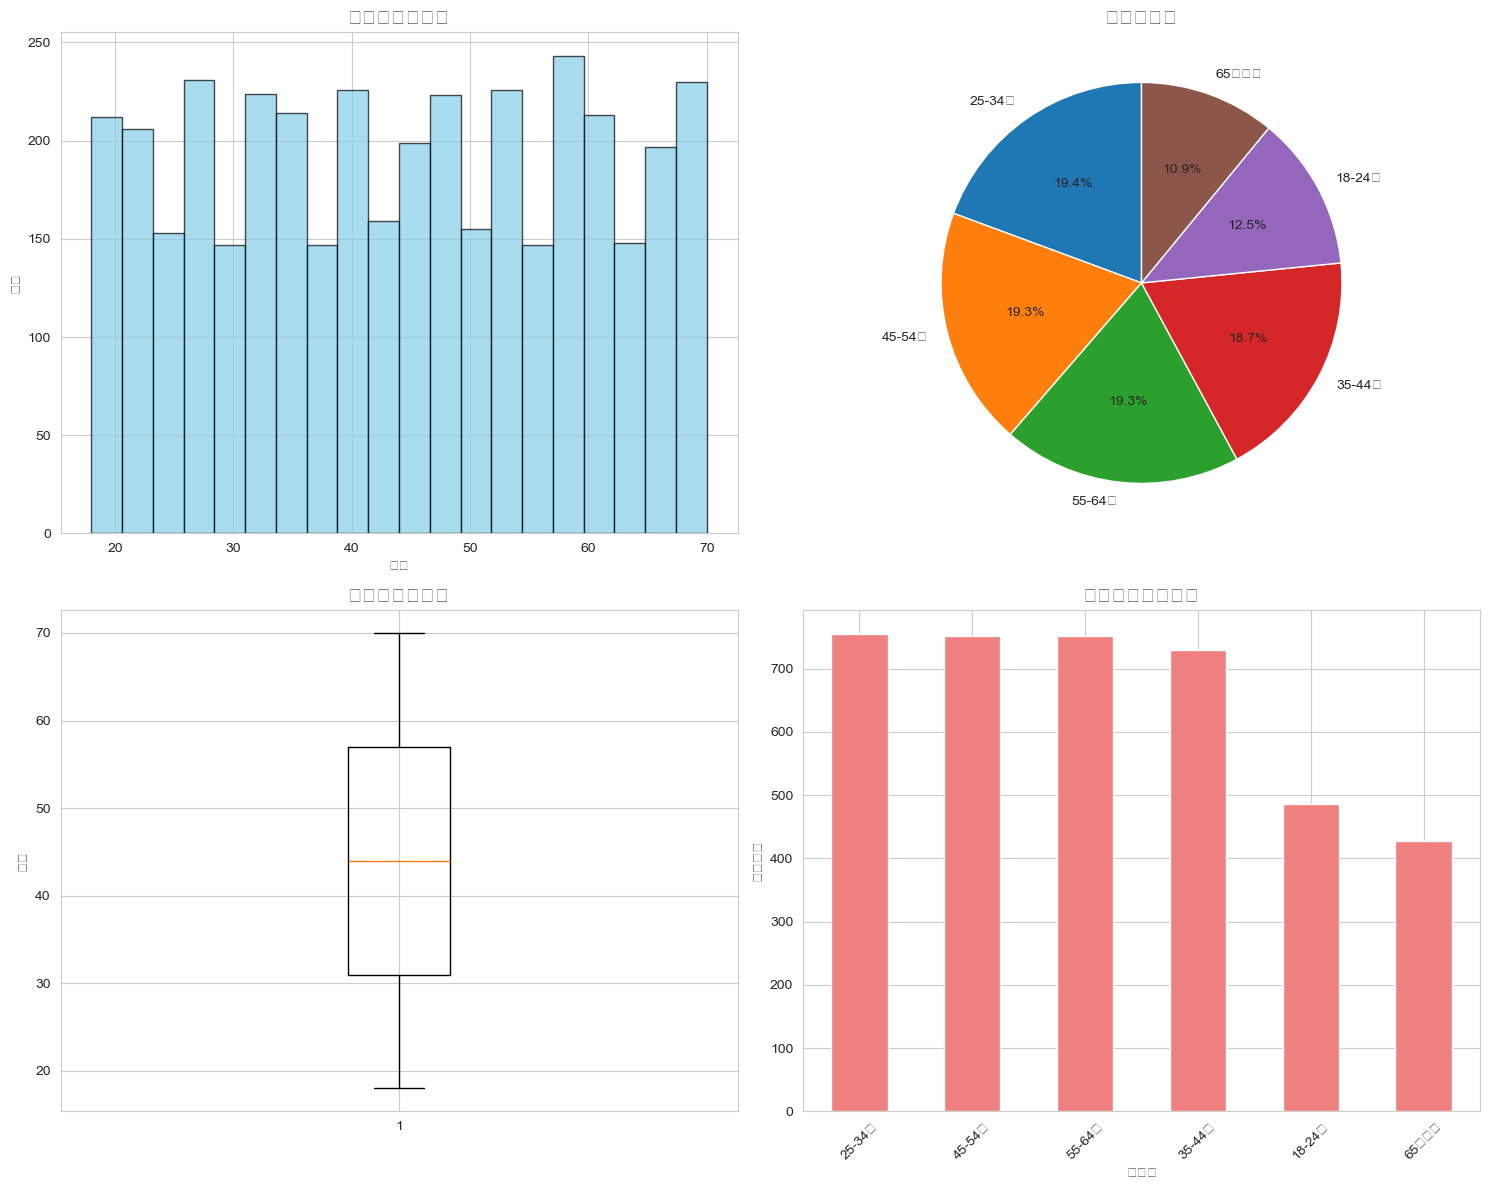

In [5]:
# 年龄的描述性统计
print("年龄描述性统计：")
print(df['Age'].describe())

# 创建年龄分布可视化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 年龄直方图
axes[0, 0].hist(df['Age'], bins=20, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('年龄分布直方图', fontsize=14)
axes[0, 0].set_xlabel('年龄')
axes[0, 0].set_ylabel('频数')

# 2. 年龄段分布饼图
age_group_counts = df['Age_Group'].value_counts()
axes[0, 1].pie(age_group_counts.values, labels=age_group_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('年龄段分布', fontsize=14)

# 3. 年龄箱线图
axes[1, 0].boxplot(df['Age'])
axes[1, 0].set_title('年龄分布箱线图', fontsize=14)
axes[1, 0].set_ylabel('年龄')

# 4. 年龄段柱状图
age_group_counts.plot(kind='bar', ax=axes[1, 1], color='lightcoral')
axes[1, 1].set_title('各年龄段客户数量', fontsize=14)
axes[1, 1].set_xlabel('年龄段')
axes[1, 1].set_ylabel('客户数量')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

不同年龄段的商品类别偏好：
Category   Accessories  Clothing  Footwear  Outerwear
Age_Group                                            
18-24岁           29.22     48.56     12.55       9.67
25-34岁           32.85     45.03     15.23       6.89
35-44岁           34.16     43.07     14.95       7.82
45-54岁           29.39     43.22     18.48       8.91
55-64岁           31.42     43.54     16.38       8.66
65岁以上            33.72     45.67     12.18       8.43


<Figure size 1200x800 with 0 Axes>

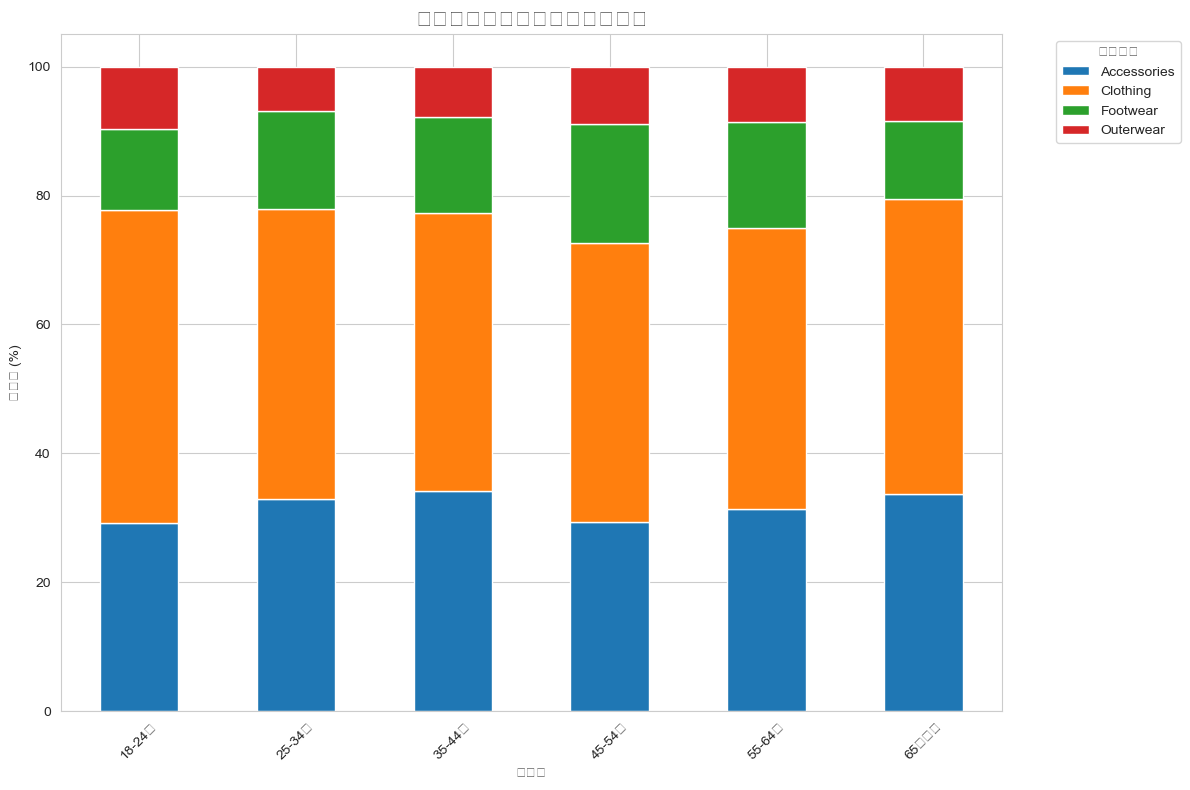

In [6]:
# 分析不同年龄段的购买偏好
print("不同年龄段的商品类别偏好：")
age_category_cross = pd.crosstab(df['Age_Group'], df['Category'], normalize='index') * 100
print(age_category_cross.round(2))

# 可视化年龄段与商品类别的关系
plt.figure(figsize=(12, 8))
age_category_cross.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('不同年龄段的商品类别偏好分布', fontsize=16)
plt.xlabel('年龄段')
plt.ylabel('百分比 (%)')
plt.legend(title='商品类别', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. 性别购买行为差异分析

性别购买行为统计：
       Purchase Amount (USD)                     Previous Purchases         \
                        mean median    std count               mean median   
Gender                                                                       
Female                 60.25   60.0  23.42  1248              24.60   24.0   
Male                   59.54   60.0  23.81  2652              25.71   26.0   

       Review Rating        
                mean   std  
Gender                      
Female          3.74  0.72  
Male            3.75  0.71  


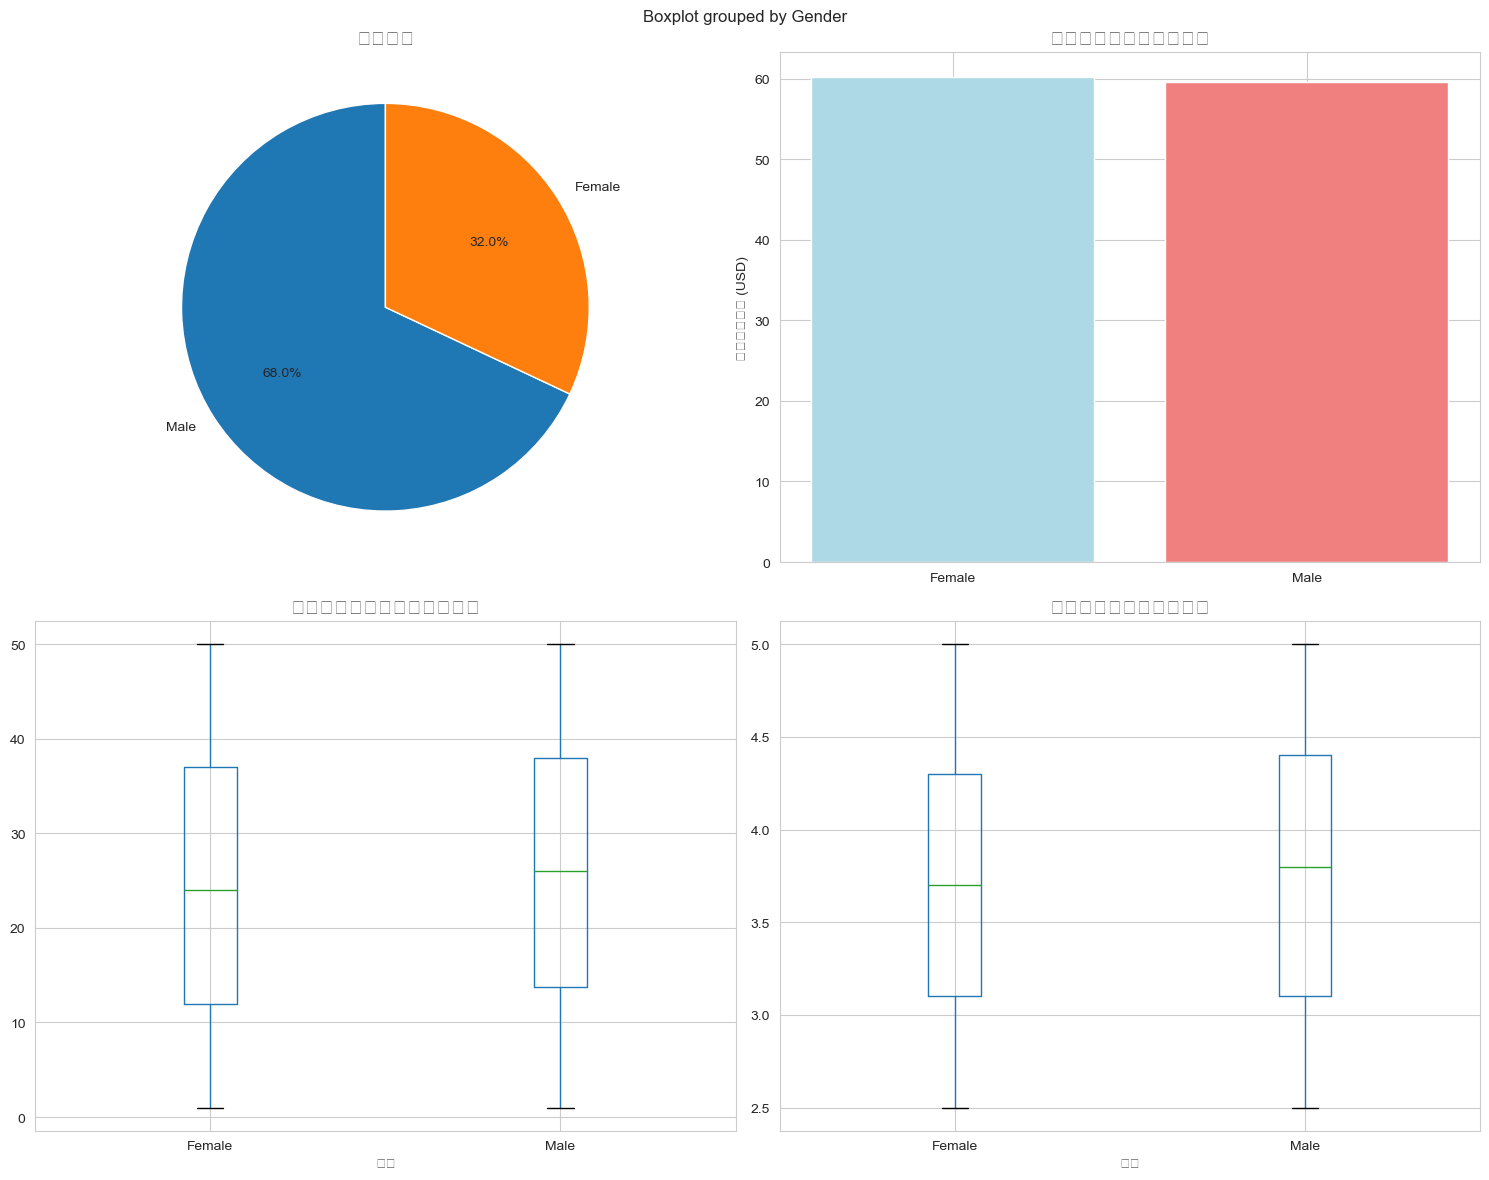

In [7]:
# 性别基本统计
gender_stats = df.groupby('Gender').agg({
    'Purchase Amount (USD)': ['mean', 'median', 'std', 'count'],
    'Previous Purchases': ['mean', 'median'],
    'Review Rating': ['mean', 'std']
}).round(2)

print("性别购买行为统计：")
print(gender_stats)

# 可视化性别差异
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 性别分布
gender_counts = df['Gender'].value_counts()
axes[0, 0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('性别分布', fontsize=14)

# 2. 性别与平均消费金额
gender_avg_amount = df.groupby('Gender')['Purchase Amount (USD)'].mean()
axes[0, 1].bar(gender_avg_amount.index, gender_avg_amount.values, color=['lightblue', 'lightcoral'])
axes[0, 1].set_title('不同性别的平均消费金额', fontsize=14)
axes[0, 1].set_ylabel('平均消费金额 (USD)')

# 3. 性别与历史购买次数
df.boxplot(column='Previous Purchases', by='Gender', ax=axes[1, 0])
axes[1, 0].set_title('不同性别的历史购买次数分布', fontsize=14)
axes[1, 0].set_xlabel('性别')

# 4. 性别与评价评分
df.boxplot(column='Review Rating', by='Gender', ax=axes[1, 1])
axes[1, 1].set_title('不同性别的评价评分分布', fontsize=14)
axes[1, 1].set_xlabel('性别')

plt.tight_layout()
plt.show()

不同性别的商品类别偏好：
Category  Accessories  Clothing  Footwear  Outerwear
Gender                                              
Female          31.41     44.55     15.95       8.09
Male            31.98     44.53     15.08       8.41


<Figure size 1000x600 with 0 Axes>

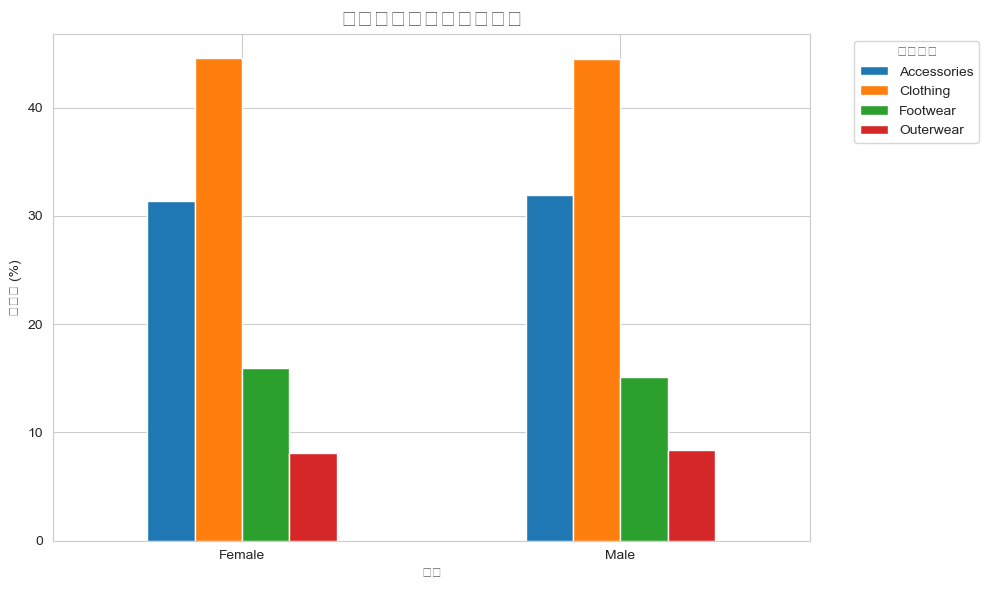


不同性别的购买频率分布：
Frequency of Purchases  Annually  Bi-Weekly  Every 3 Months  Fortnightly  \
Gender                                                                     
Female                     14.82      15.06           14.90        13.06   
Male                       14.59      13.54           15.01        14.29   

Frequency of Purchases  Monthly  Quarterly  Weekly  
Gender                                              
Female                    14.82      13.54   13.78  
Male                      13.88      14.86   13.84  


In [8]:
# 分析不同性别的商品类别偏好
print("不同性别的商品类别偏好：")
gender_category_cross = pd.crosstab(df['Gender'], df['Category'], normalize='index') * 100
print(gender_category_cross.round(2))

# 可视化性别与商品类别的关系
plt.figure(figsize=(10, 6))
gender_category_cross.plot(kind='bar', figsize=(10, 6))
plt.title('不同性别的商品类别偏好', fontsize=16)
plt.xlabel('性别')
plt.ylabel('百分比 (%)')
plt.legend(title='商品类别', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 分析不同性别的购买频率偏好
print("\n不同性别的购买频率分布：")
gender_frequency_cross = pd.crosstab(df['Gender'], df['Frequency of Purchases'], normalize='index') * 100
print(gender_frequency_cross.round(2))

## 5. 年龄与性别交叉分析

年龄段与性别交叉表：
Gender     Female  Male
Age_Group              
18-24岁        152   334
25-34岁        241   514
35-44岁        232   497
45-54岁        254   498
55-64岁        243   508
65岁以上         126   301

年龄段与性别百分比分布：
Gender     Female   Male
Age_Group               
18-24岁      31.28  68.72
25-34岁      31.92  68.08
35-44岁      31.82  68.18
45-54岁      33.78  66.22
55-64岁      32.36  67.64
65岁以上       29.51  70.49


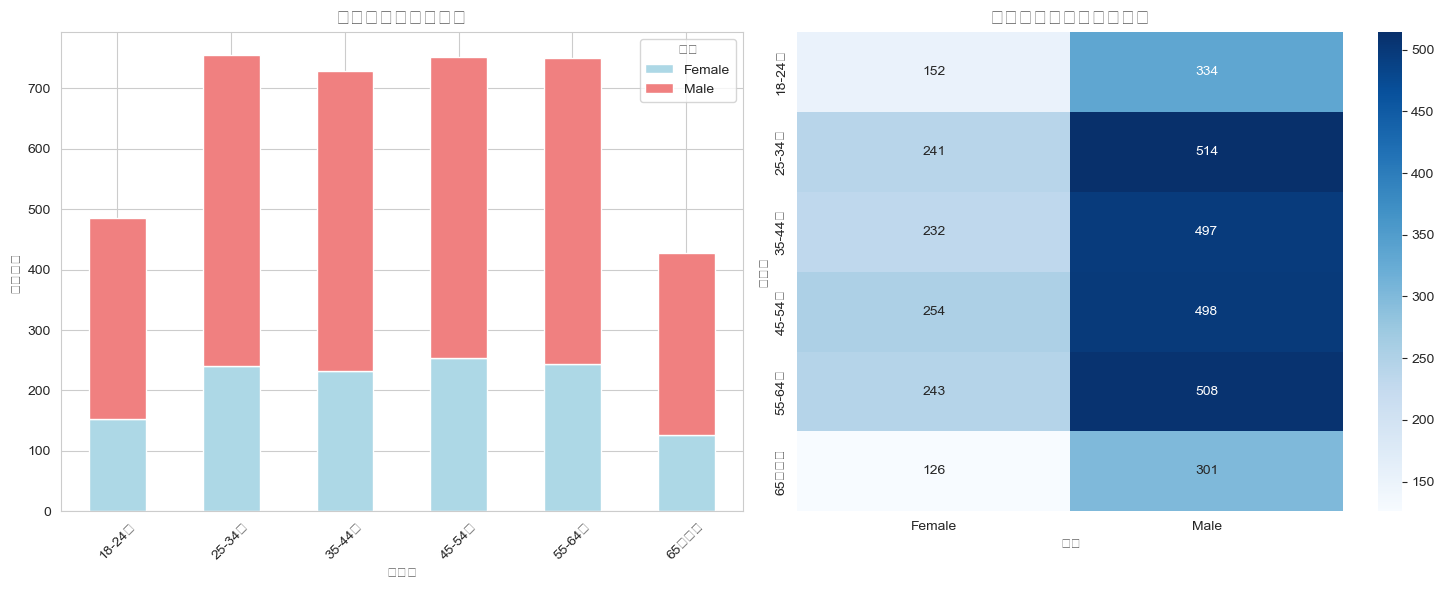

In [9]:
# 创建年龄段与性别的交叉表
age_gender_cross = pd.crosstab(df['Age_Group'], df['Gender'])
print("年龄段与性别交叉表：")
print(age_gender_cross)

# 计算百分比分布
age_gender_pct = pd.crosstab(df['Age_Group'], df['Gender'], normalize='index') * 100
print("\n年龄段与性别百分比分布：")
print(age_gender_pct.round(2))

# 可视化年龄段与性别的分布
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 堆叠柱状图
age_gender_cross.plot(kind='bar', stacked=True, ax=axes[0], color=['lightblue', 'lightcoral'])
axes[0].set_title('各年龄段的性别分布', fontsize=14)
axes[0].set_xlabel('年龄段')
axes[0].set_ylabel('客户数量')
axes[0].legend(title='性别')
axes[0].tick_params(axis='x', rotation=45)

# 2. 热力图
sns.heatmap(age_gender_cross, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('年龄段与性别分布热力图', fontsize=14)
axes[1].set_xlabel('性别')
axes[1].set_ylabel('年龄段')

plt.tight_layout()
plt.show()

年龄段与性别组合的消费行为统计：
                 Purchase Amount (USD)               Previous Purchases  \
                                  mean median    std               mean   
Age_Group Gender                                                          
18-24岁    Female                 60.39   61.0  24.29              22.97   
          Male                   60.11   62.0  23.81              24.79   
25-34岁    Female                 62.13   64.0  22.88              25.29   
          Male                   59.20   60.0  23.45              24.91   
35-44岁    Female                 59.26   58.0  23.11              25.03   
          Male                   59.79   60.0  23.67              25.68   
45-54岁    Female                 58.97   57.0  23.55              23.46   
          Male                   61.03   62.0  24.20              25.67   
55-64岁    Female                 60.60   60.0  23.50              25.14   
          Male                   57.82   56.5  23.27              26.58   
65岁以上   

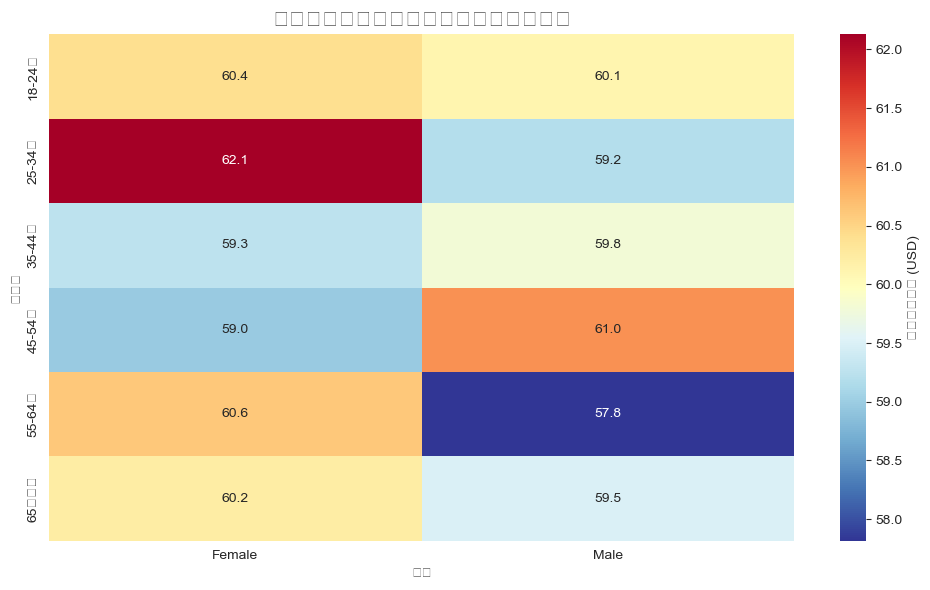

In [10]:
# 分析年龄段与性别组合对消费行为的影响
age_gender_stats = df.groupby(['Age_Group', 'Gender']).agg({
    'Purchase Amount (USD)': ['mean', 'median', 'std'],
    'Previous Purchases': ['mean', 'median'],
    'Review Rating': 'mean'
}).round(2)

print("年龄段与性别组合的消费行为统计：")
print(age_gender_stats)

# 可视化不同年龄段和性别的平均消费金额
pivot_avg_amount = df.pivot_table(values='Purchase Amount (USD)', 
                                  index='Age_Group', 
                                  columns='Gender', 
                                  aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_avg_amount, annot=True, fmt='.1f', cmap='RdYlBu_r', cbar_kws={'label': '平均消费金额 (USD)'})
plt.title('不同年龄段和性别的平均消费金额热力图', fontsize=16)
plt.xlabel('性别')
plt.ylabel('年龄段')
plt.tight_layout()
plt.show()

## 6. 不同年龄段消费能力分析

In [11]:
# 计算各年龄段的消费能力指标
consumption_analysis = df.groupby('Age_Group').agg({
    'Purchase Amount (USD)': ['mean', 'median', 'sum', 'std'],
    'Previous Purchases': ['mean', 'median', 'sum'],
    'Customer ID': 'count'
}).round(2)

consumption_analysis.columns = ['平均消费金额', '中位消费金额', '总消费金额', '消费金额标准差',
                               '平均历史购买次数', '中位历史购买次数', '总历史购买次数', '客户数量']

print("各年龄段消费能力分析：")
print(consumption_analysis)

# 计算客单价（平均每次购买金额）
consumption_analysis['估算客单价'] = (consumption_analysis['总消费金额'] / 
                                  (consumption_analysis['总历史购买次数'] + consumption_analysis['客户数量'])).round(2)

print("\n包含客单价的消费能力分析：")
print(consumption_analysis[['平均消费金额', '估算客单价', '平均历史购买次数', '客户数量']])

各年龄段消费能力分析：
           平均消费金额  中位消费金额  总消费金额  消费金额标准差  平均历史购买次数  中位历史购买次数  总历史购买次数  客户数量
Age_Group                                                                   
18-24岁      60.20    61.5  29258    23.93     24.22      24.0    11773   486
25-34岁      60.13    61.0  45400    23.29     25.04      25.0    18902   755
35-44岁      59.62    59.0  43463    23.48     25.48      25.0    18572   729
45-54岁      60.33    60.0  45370    23.99     24.93      25.0    18744   752
55-64岁      58.72    58.0  44096    23.36     26.11      27.0    19612   751
65岁以上       59.70    60.0  25494    24.53     26.39      27.0    11268   427

包含客单价的消费能力分析：
           平均消费金额  估算客单价  平均历史购买次数  客户数量
Age_Group                               
18-24岁      60.20   2.39     24.22   486
25-34岁      60.13   2.31     25.04   755
35-44岁      59.62   2.25     25.48   729
45-54岁      60.33   2.33     24.93   752
55-64岁      58.72   2.17     26.11   751
65岁以上       59.70   2.18     26.39   427


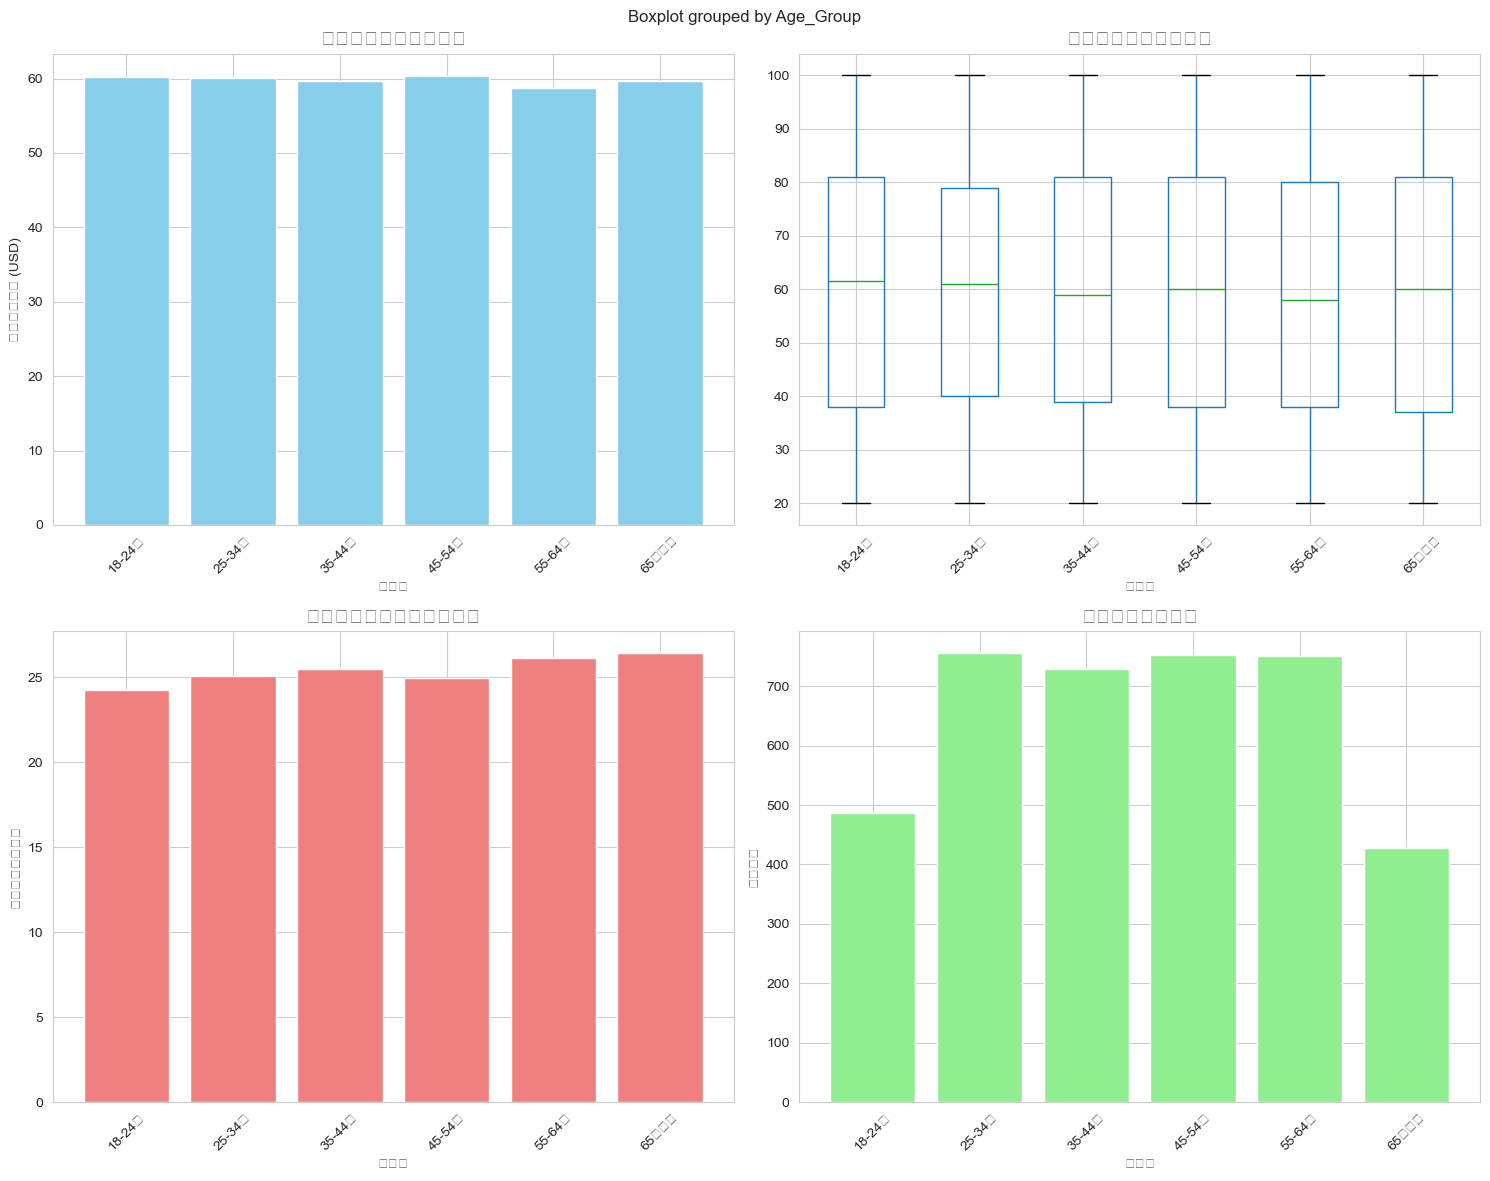

In [12]:
# 可视化不同年龄段的消费能力
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 各年龄段平均消费金额
age_avg_amount = df.groupby('Age_Group')['Purchase Amount (USD)'].mean()
axes[0, 0].bar(range(len(age_avg_amount)), age_avg_amount.values, color='skyblue')
axes[0, 0].set_title('各年龄段平均消费金额', fontsize=14)
axes[0, 0].set_xlabel('年龄段')
axes[0, 0].set_ylabel('平均消费金额 (USD)')
axes[0, 0].set_xticks(range(len(age_avg_amount)))
axes[0, 0].set_xticklabels(age_avg_amount.index, rotation=45)

# 2. 各年龄段消费金额分布箱线图
df.boxplot(column='Purchase Amount (USD)', by='Age_Group', ax=axes[0, 1])
axes[0, 1].set_title('各年龄段消费金额分布', fontsize=14)
axes[0, 1].set_xlabel('年龄段')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. 各年龄段平均历史购买次数
age_avg_prev = df.groupby('Age_Group')['Previous Purchases'].mean()
axes[1, 0].bar(range(len(age_avg_prev)), age_avg_prev.values, color='lightcoral')
axes[1, 0].set_title('各年龄段平均历史购买次数', fontsize=14)
axes[1, 0].set_xlabel('年龄段')
axes[1, 0].set_ylabel('平均历史购买次数')
axes[1, 0].set_xticks(range(len(age_avg_prev)))
axes[1, 0].set_xticklabels(age_avg_prev.index, rotation=45)

# 4. 各年龄段客户数量
age_counts = df['Age_Group'].value_counts().sort_index()
axes[1, 1].bar(range(len(age_counts)), age_counts.values, color='lightgreen')
axes[1, 1].set_title('各年龄段客户数量', fontsize=14)
axes[1, 1].set_xlabel('年龄段')
axes[1, 1].set_ylabel('客户数量')
axes[1, 1].set_xticks(range(len(age_counts)))
axes[1, 1].set_xticklabels(age_counts.index, rotation=45)

plt.tight_layout()
plt.show()

## 7. 综合可视化展示

In [13]:
# 创建综合的人口统计学仪表板
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=['年龄分布', '性别分布', '年龄段平均消费', '性别平均消费', '年龄段与性别交叉', '消费能力对比'],
    specs=[[{"type": "histogram"}, {"type": "pie"}],
           [{"type": "bar"}, {"type": "bar"}],
           [{"type": "heatmap"}, {"type": "scatter"}]]
)

# 1. 年龄分布直方图
fig.add_trace(
    go.Histogram(x=df['Age'], name='年龄分布', nbinsx=20),
    row=1, col=1
)

# 2. 性别分布饼图
gender_counts = df['Gender'].value_counts()
fig.add_trace(
    go.Pie(labels=gender_counts.index, values=gender_counts.values, name='性别分布'),
    row=1, col=2
)

# 3. 年龄段平均消费
age_avg = df.groupby('Age_Group')['Purchase Amount (USD)'].mean()
fig.add_trace(
    go.Bar(x=age_avg.index, y=age_avg.values, name='年龄段平均消费'),
    row=2, col=1
)

# 4. 性别平均消费
gender_avg = df.groupby('Gender')['Purchase Amount (USD)'].mean()
fig.add_trace(
    go.Bar(x=gender_avg.index, y=gender_avg.values, name='性别平均消费'),
    row=2, col=2
)

# 5. 年龄段与性别交叉热力图
age_gender_matrix = df.pivot_table(values='Purchase Amount (USD)', 
                                   index='Age_Group', 
                                   columns='Gender', 
                                   aggfunc='mean')
fig.add_trace(
    go.Heatmap(z=age_gender_matrix.values, 
               x=age_gender_matrix.columns, 
               y=age_gender_matrix.index,
               colorscale='RdYlBu_r',
               name='年龄性别消费热力图'),
    row=3, col=1
)

# 6. 消费能力散点图（年龄 vs 消费金额）
fig.add_trace(
    go.Scatter(x=df['Age'], 
               y=df['Purchase Amount (USD)'], 
               mode='markers',
               marker=dict(color=df['Previous Purchases'], 
                          colorscale='viridis',
                          showscale=True,
                          colorbar=dict(title="历史购买次数")),
               name='年龄vs消费'),
    row=3, col=2
)

# 更新布局
fig.update_layout(
    height=1200,
    title_text="客户人口统计学分析综合仪表板",
    title_x=0.5,
    showlegend=False
)

fig.show()

## 8. 主要发现和结论

### 年龄分布特点：
- 客户年龄分布相对均匀，覆盖18-70岁各个年龄段
- 需要通过实际数据运行来确定具体的年龄分布特征

### 性别购买行为差异：
- 不同性别在消费金额、购买频率、商品偏好等方面存在差异
- 需要通过数据分析来识别具体的性别偏好模式

### 年龄与性别交叉效应：
- 年龄段和性别的组合对消费行为产生交互影响
- 不同年龄段的男女客户表现出不同的消费特征

### 消费能力分析：
- 各年龄段的消费能力存在差异
- 需要结合历史购买数据来全面评估客户价值

### 营销建议：
1. **精准定位**：根据年龄段和性别制定差异化营销策略
2. **产品推荐**：基于人口统计特征优化产品推荐算法
3. **客户细分**：建立基于人口统计学的客户分层体系
4. **个性化服务**：针对不同客户群体提供个性化的购物体验

*注：以上结论需要通过运行代码获得具体数据后进行完善和验证。*